In [8]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [9]:
#Load Preprocessed Data
DATA_DIR = "data/processed"


X_train = np.load(f"{DATA_DIR}/X_train.npy")
Y_train = np.load(f"{DATA_DIR}/Y_train.npy")
X_val = np.load(f"{DATA_DIR}/X_val.npy")
Y_val = np.load(f"{DATA_DIR}/Y_val.npy")
X_test = np.load(f"{DATA_DIR}/X_test.npy")
Y_test = np.load(f"{DATA_DIR}/Y_test.npy")


print(X_train.shape, Y_train.shape)

(69, 12, 2, 201, 281) (69, 6, 2, 201, 281)


In [10]:
#PyTorch Dataset
from torch.utils.data import Dataset, DataLoader

class WindDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Create datasets and data loaders
BATCH_SIZE = 2

train_ds = WindDataset(X_train, Y_train)
val_ds = WindDataset(X_val, Y_val)
test_ds = WindDataset(X_test, Y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data loaders created successfully!")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Data loaders created successfully!
Train batches: 35, Val batches: 6, Test batches: 7


In [11]:
#ConvLSTM Cell
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size,
            padding=padding
        )
        self.hidden_channels = hidden_channels

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

In [ ]:
#ConvLSTM Model
class ConvLSTM(nn.Module):
    def __init__(self, in_channels=2, hidden_channels=32, out_steps=6):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.cell = ConvLSTMCell(in_channels, hidden_channels)
        self.out_steps = out_steps
        self.conv_out = nn.Conv2d(hidden_channels, in_channels, kernel_size=1)

    def forward(self, x):
    # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        h = torch.zeros(B, self.hidden_channels, H, W, device=x.device)
        c = torch.zeros_like(h)

        for t in range(T):
            h, c = self.cell(x[:, t], h, c)

        outputs = []
        for _ in range(self.out_steps):
            h, c = self.cell(self.conv_out(h), h, c)
            outputs.append(self.conv_out(h))

        return torch.stack(outputs, dim=1)

In [13]:
#Training Setup
model = ConvLSTM().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [19]:
#Training Loop
EPOCHS = 20


for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0


    for X, Y in train_loader:
        X, Y = X.to(device), Y.to(device)
        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds, Y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)


    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            preds = model(X)
            val_loss += criterion(preds, Y).item()

    val_loss /= len(val_loader)


    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/20 | Train Loss: 0.1715 | Val Loss: 0.1983
Epoch 2/20 | Train Loss: 0.1689 | Val Loss: 0.2118
Epoch 3/20 | Train Loss: 0.1781 | Val Loss: 0.1857
Epoch 4/20 | Train Loss: 0.1657 | Val Loss: 0.1850
Epoch 5/20 | Train Loss: 0.1727 | Val Loss: 0.1911
Epoch 6/20 | Train Loss: 0.1749 | Val Loss: 0.1845
Epoch 7/20 | Train Loss: 0.1682 | Val Loss: 0.1797
Epoch 8/20 | Train Loss: 0.1636 | Val Loss: 0.1812
Epoch 9/20 | Train Loss: 0.1584 | Val Loss: 0.1848
Epoch 10/20 | Train Loss: 0.1613 | Val Loss: 0.2204
Epoch 11/20 | Train Loss: 0.1529 | Val Loss: 0.1779
Epoch 12/20 | Train Loss: 0.1598 | Val Loss: 0.1802
Epoch 13/20 | Train Loss: 0.1580 | Val Loss: 0.1713
Epoch 14/20 | Train Loss: 0.1572 | Val Loss: 0.2393
Epoch 15/20 | Train Loss: 0.1707 | Val Loss: 0.1980
Epoch 16/20 | Train Loss: 0.1538 | Val Loss: 0.1768
Epoch 17/20 | Train Loss: 0.1539 | Val Loss: 0.2258
Epoch 18/20 | Train Loss: 0.1548 | Val Loss: 0.1980
Epoch 19/20 | Train Loss: 0.1455 | Val Loss: 0.1819
Epoch 20/20 | Train L

In [31]:
#Test Evaluation
model.eval()
test_loss = 0.0
Y_pred_test = []
Y_test_torch = []

with torch.no_grad():
    for X, Y in test_loader:
        X, Y = X.to(device), Y.to(device)
        preds = model(X)
        test_loss += criterion(preds, Y).item()
        # Collect predictions and targets
        Y_pred_test.append(preds.cpu().numpy())
        Y_test_torch.append(Y.cpu().numpy())

test_loss /= len(test_loader)
print("Test MSE:", test_loss)

# Convert to numpy arrays
Y_pred_test = np.concatenate(Y_pred_test, axis=0)
Y_test_torch = np.concatenate(Y_test_torch, axis=0)
print(f"Y_pred_test shape: {Y_pred_test.shape}")
print(f"Y_test shape: {Y_test_torch.shape}")

Test MSE: 0.1335765410746847
Y_pred_test shape: (13, 6, 2, 201, 281)
Y_test shape: (13, 6, 2, 201, 281)


In [24]:
torch.save(model.state_dict(), "convlstm.pt")


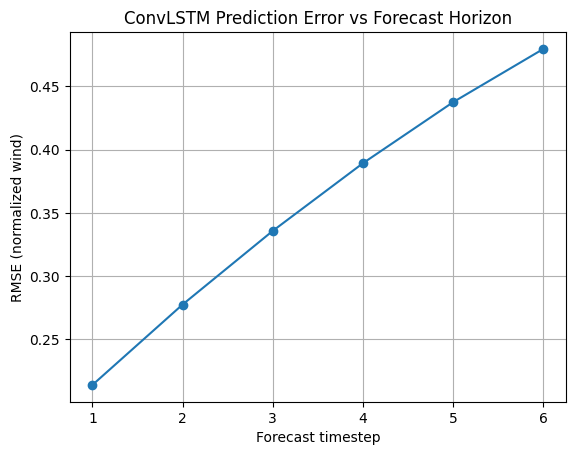

In [34]:
#PREDICTED VS TARGET RMSE OVER TIME
import numpy as np
import matplotlib.pyplot as plt

# y_pred, y_true: [N, T_out, 2, H, W]
def rmse_per_timestep(y_pred, y_true):
    rmses = []
    for t in range(y_true.shape[1]):
        mse = np.mean((y_pred[:, t] - y_true[:, t])**2)
        rmses.append(np.sqrt(mse))
    return rmses

# Use the collected test data (Y_test_torch) or original Y_test
# Both should be the same, but Y_test_torch is from the loader batches
rmse_curve = rmse_per_timestep(Y_pred_test, Y_test_torch)

plt.plot(range(1, len(rmse_curve)+1), rmse_curve, marker='o')
plt.xlabel("Forecast timestep")
plt.ylabel("RMSE (normalized wind)")
plt.title("ConvLSTM Prediction Error vs Forecast Horizon")
plt.grid(True)
plt.show()


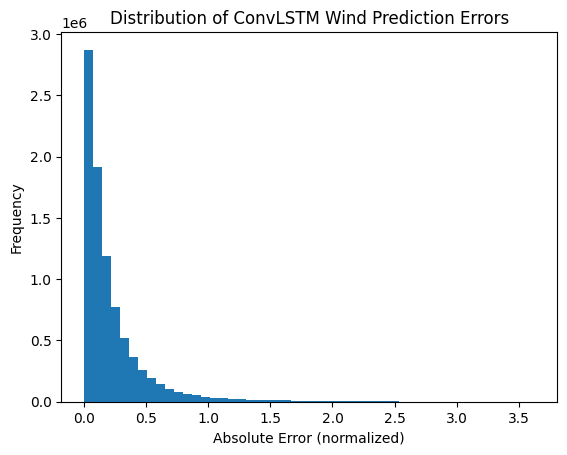

In [35]:
abs_err = np.abs(Y_pred_test - Y_test).flatten()

plt.hist(abs_err, bins=50)
plt.xlabel("Absolute Error (normalized)")
plt.ylabel("Frequency")
plt.title("Distribution of ConvLSTM Wind Prediction Errors")
plt.show()


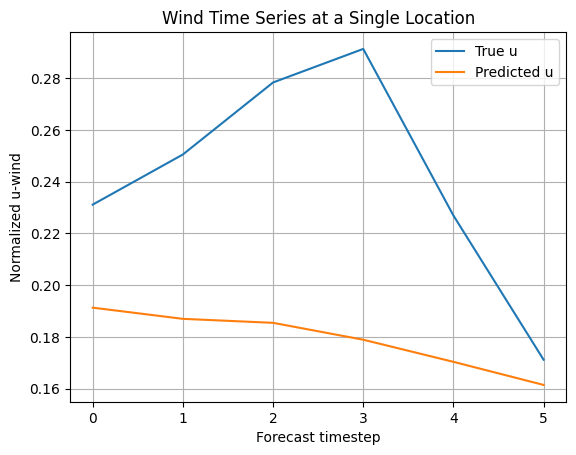

In [32]:
i, j = 100, 150  # any grid point

true_u = Y_test[0, :, 0, i, j]
pred_u = Y_pred_test[0, :, 0, i, j]

plt.plot(true_u, label="True u")
plt.plot(pred_u, label="Predicted u")
plt.legend()
plt.xlabel("Forecast timestep")
plt.ylabel("Normalized u-wind")
plt.title("Wind Time Series at a Single Location")
plt.grid(True)
plt.show()


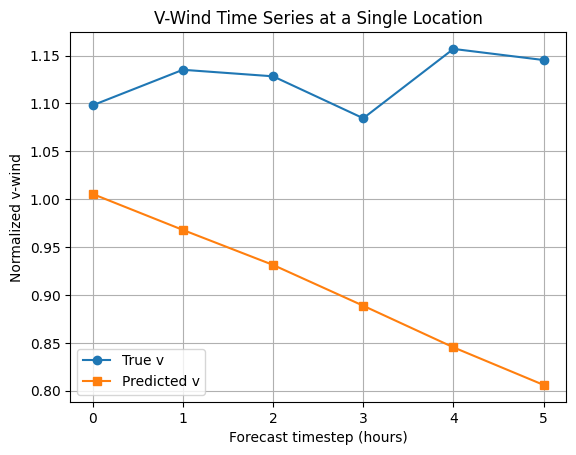

In [ ]:
i, j = 100, 150  # same grid point as u-wind plot

true_v = Y_test_torch[0, :, 1, i, j]  # v-wind component (index 1)
pred_v = Y_pred_test[0, :, 1, i, j]

plt.plot(true_v, label="True v", marker='o')
plt.plot(pred_v, label="Predicted v", marker='s')
plt.legend()
plt.xlabel("Forecast timestep (hours)")
plt.ylabel("Normalized v-wind")
plt.title("V-Wind Time Series at a Single Location")
plt.grid(True)
plt.show()
